# Notebook 2 — CWRU Bearing Fault Detection

**Dataset:** Case Western Reserve University (CWRU) Bearing Dataset — drive-end accelerometer at 12 kHz, 0 HP load.  
**Conditions:** Normal, Inner Race fault (0.007"), Ball fault (0.007"), Outer Race fault (0.007" @ 6 o'clock).  
**Goal:** Train only on normal data, then detect faults as anomalies.  
**Models:** Isolation Forest (feature-based) + Conv1d Autoencoder (raw signal).  
**Metric:** PR-AUC under a position-based (non-leaky) train/test split.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

from src.data_loader import load_cwru
from src.preprocessing import sliding_windows_cwru
from src.features import extract_features
from src.models import fit_isolation_forest, ConvAutoencoder, train_autoencoder
from src.evaluate import pr_auc, threshold_sweep, plot_threshold_tradeoff, plot_score_distribution

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

FS = 12_000  # sampling rate Hz

Device: cpu


## 1. Load Signals

In [4]:
signals = load_cwru('../data/cwru')
for label, sig in signals.items():
    duration = len(sig) / FS
    print(f'  {label:12s}: {len(sig):>7,} samples  ({duration:.1f} s)')

  normal      : 483,903 samples  (40.3 s)
  inner_race  : 486,224 samples  (40.5 s)
  ball        : 487,384 samples  (40.6 s)
  outer_race  : 486,804 samples  (40.6 s)


## 2. Visualise Raw Signals

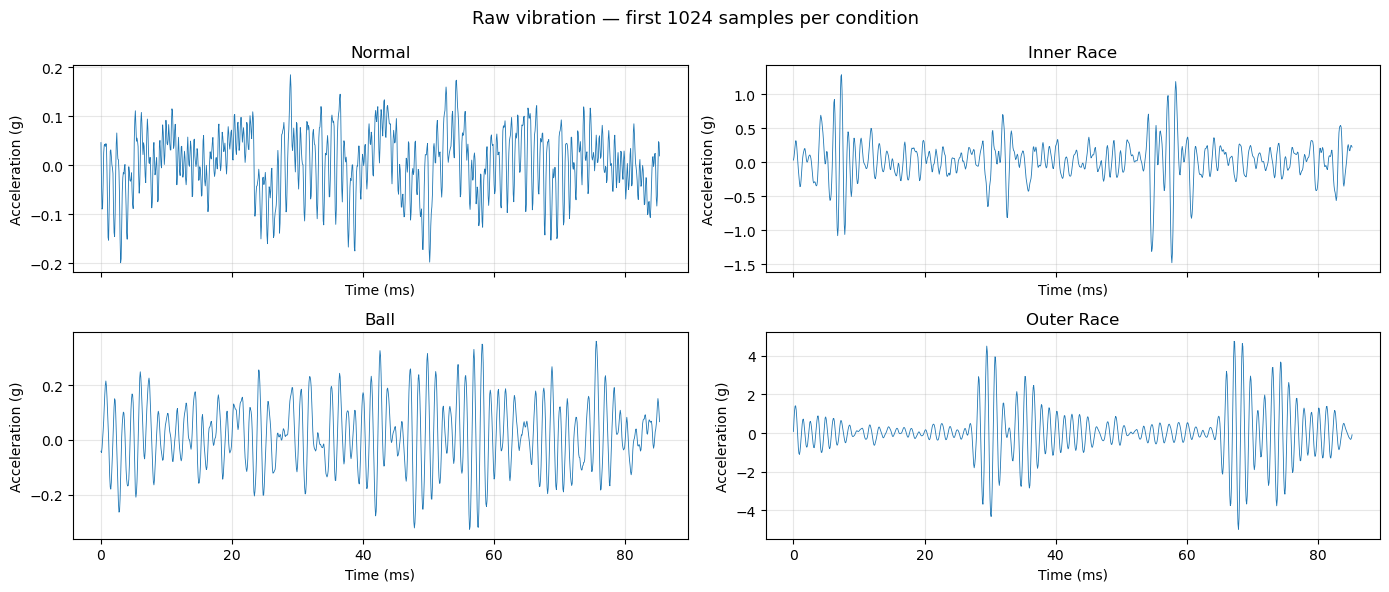

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
for ax, (label, sig) in zip(axes.ravel(), signals.items()):
    t = np.arange(1024) / FS * 1000  # ms
    ax.plot(t, sig[:1024], linewidth=0.6)
    ax.set_title(label.replace('_', ' ').title())
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Acceleration (g)')
    ax.grid(alpha=0.3)
plt.suptitle('Raw vibration — first 1024 samples per condition', fontsize=13)
plt.tight_layout(); plt.show()

## 3. FFT Comparison — Fault Frequencies in Spectrum

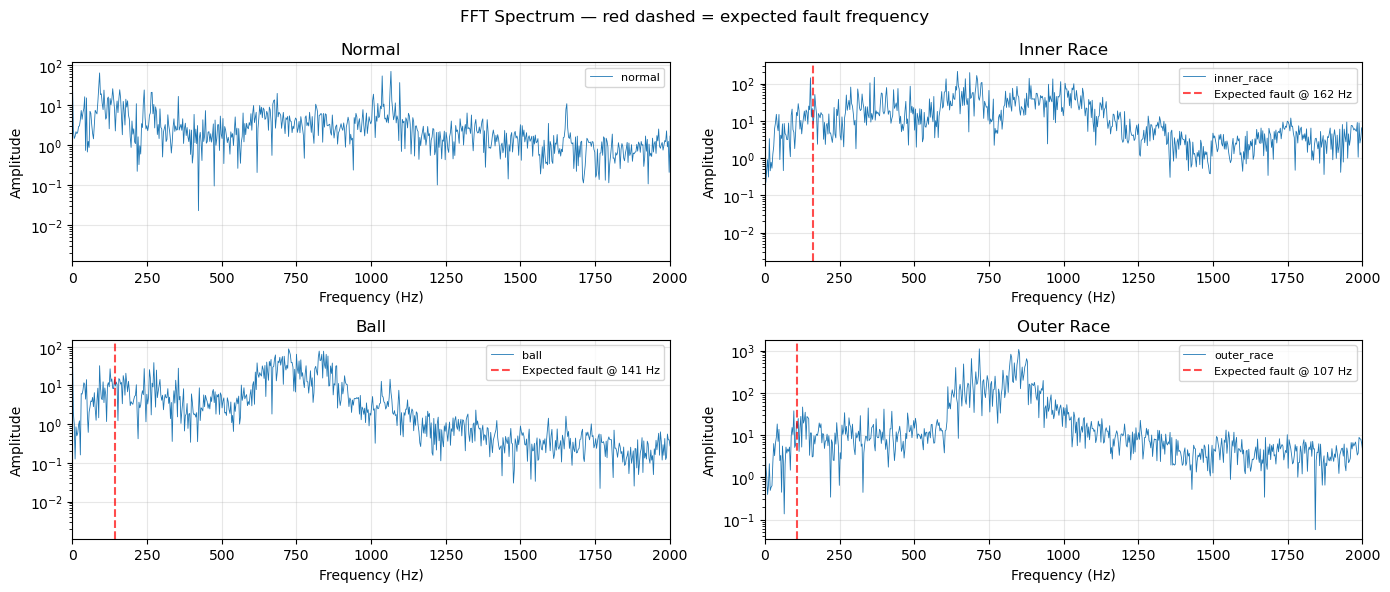

In [8]:
# Characteristic fault frequencies (approximate, 1797 RPM motor, 6-ball bearing)
# BPFI (inner race) ≈ 162 Hz, BPFO (outer race) ≈ 107 Hz, BSF (ball) ≈ 141 Hz
fault_freqs = {'inner_race': 162, 'outer_race': 107, 'ball': 141}

N = 4096
freqs = fftfreq(N, d=1/FS)[:N//2]

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax, (label, sig) in zip(axes.ravel(), signals.items()):
    spectrum = np.abs(fft(sig[:N]))[:N//2]
    ax.semilogy(freqs, spectrum, linewidth=0.6, label=label)
    if label in fault_freqs:
        ax.axvline(fault_freqs[label], color='red', linestyle='--', alpha=0.7,
                   label=f'Expected fault @ {fault_freqs[label]} Hz')
    ax.set_title(label.replace('_', ' ').title())
    ax.set_xlim(0, 2000)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('FFT Spectrum — red dashed = expected fault frequency', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Windowing with Honest Train/Test Split

### ⚠️ Critical: Split by Position, Not Randomly

Adjacent vibration windows from the same recording are **temporally correlated** — they share nearly identical content. A random train/test split would put almost-duplicate windows in both sets, inflating test metrics without measuring real generalisation.

**This approach:**
- Normal signal: first 60% → training, last 40% → test  
- Fault signals: entirely in test (separate recording files, no overlap possible)

**Result:** Conservative, honest PR-AUC. The model has never seen the test-set normal windows OR any fault windows. This is the correct benchmark framing.

In [10]:
WINDOW = 1024
STRIDE = 512

normal_sig = signals['normal']
split_idx  = int(len(normal_sig) * 0.6)

normal_train_windows = sliding_windows_cwru(normal_sig[:split_idx], WINDOW, STRIDE)
normal_test_windows  = sliding_windows_cwru(normal_sig[split_idx:], WINDOW, STRIDE)

fault_windows = {k: sliding_windows_cwru(v, WINDOW, STRIDE)
                 for k, v in signals.items() if k != 'normal'}

print(f'Normal train windows : {len(normal_train_windows)}')
print(f'Normal test  windows : {len(normal_test_windows)}')
for k, w in fault_windows.items():
    print(f'  {k:12s} windows: {len(w)}')

Normal train windows : 566
Normal test  windows : 377
  inner_race   windows: 948
  ball         windows: 950
  outer_race   windows: 949


## 5. Extract Statistical Features

Feature matrix shape (normal train): (566, 4)
Feature columns: [rms, kurtosis, peak_to_peak, spectral_entropy]


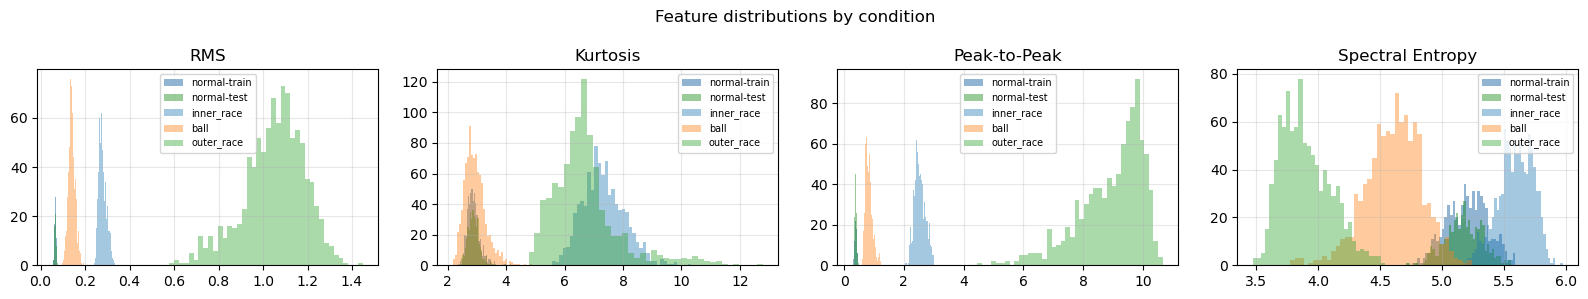

In [12]:
X_normal_train = extract_features(normal_train_windows)   # shape (n, 4)
X_normal_test  = extract_features(normal_test_windows)
X_fault = {k: extract_features(w) for k, w in fault_windows.items()}

print(f'Feature matrix shape (normal train): {X_normal_train.shape}')
print('Feature columns: [rms, kurtosis, peak_to_peak, spectral_entropy]')

# Feature distributions
feat_names = ['RMS', 'Kurtosis', 'Peak-to-Peak', 'Spectral Entropy']
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, (ax, fname) in enumerate(zip(axes, feat_names)):
    ax.hist(X_normal_train[:, i], bins=40, alpha=0.6, label='normal-train', color='steelblue')
    ax.hist(X_normal_test[:, i],  bins=40, alpha=0.4, label='normal-test',  color='green')
    for k, Xf in X_fault.items():
        ax.hist(Xf[:, i], bins=40, alpha=0.4, label=k)
    ax.set_title(fname); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle('Feature distributions by condition', fontsize=12)
plt.tight_layout(); plt.show()

## 6. Isolation Forest (Normal-Only Training)

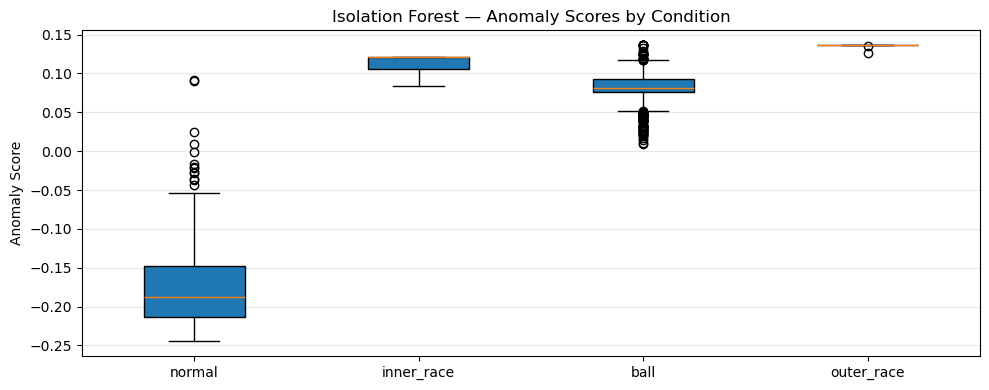

Isolation Forest PR-AUC: 0.9998


In [14]:
iforest = fit_isolation_forest(X_normal_train, contamination=0.01)

# Score all conditions (decision_function: lower = more anomalous)
# Negate so higher = more anomalous (consistent with PR-AUC convention)
if_scores = {
    'normal': -iforest.decision_function(X_normal_test),
    **{k: -iforest.decision_function(Xf) for k, Xf in X_fault.items()}
}

plot_score_distribution(if_scores, 'Isolation Forest — Anomaly Scores by Condition')
plt.show()

# Build binary labels: 0=normal, 1=fault
all_scores_if = np.concatenate([if_scores['normal']] + [if_scores[k] for k in fault_windows])
all_labels    = np.concatenate([
    np.zeros(len(if_scores['normal'])),
    np.ones(sum(len(if_scores[k]) for k in fault_windows))
])

pr_auc_if = pr_auc(all_labels, all_scores_if)
print(f'Isolation Forest PR-AUC: {pr_auc_if:.4f}')

## 7. Conv1d Autoencoder (Normal-Only Training)

### Why train only on normal data?

In production, bearing failures are rare events. You might have 10,000 hours of normal operation and 3 documented failures — training a binary classifier on this is pathological (class imbalance, never-seen failure modes).

The unsupervised approach: **teach the model what 'healthy' looks like.** The autoencoder learns to reconstruct normal vibration patterns. At inference, anything the model has never seen — any novel fault pattern, even one not in training data — will have high reconstruction error. This also handles fault modes that weren't documented, which matters enormously in real plants.

### 💡 Explain This: Why Train Only on Normal Data?

In production, failures are rare by definition. You might have 50,000 hours of normal motor operation and 3 documented bearing failures. A supervised classifier trained on this is pathological — it learns 'predict normal always' and achieves 99.99% accuracy. Accuracy is a useless metric here.

The unsupervised approach inverts the problem: **teach the model the manifold of healthy behavior.** Anything that deviates from that manifold is anomalous — even novel failure modes the model has never seen.

**What reconstruction error means:** The autoencoder compresses a window to a latent vector and reconstructs it. Trained only on normal windows, the decoder learned 'what normal vibration looks like.' A fault window gets reconstructed as what the decoder *expects* — not what the fault actually is. MSE(input, reconstruction) = anomaly score. High error = the motor is doing something outside the learned normal manifold.

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=32, bias=True)
    (8): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=2048, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(32, 64))
    (3): Upsample(scale_factor=4.0, mode='nearest')
    (4): Conv1d(32, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): Upsample(scale_factor=4.0, mode='nearest')
    (7): Conv1d(16, 1, kernel_size=(7,), stride=(1,), padding=(3,))
  )
)
  Epoch 5/30  loss=0.004272
  Epoch 10/30  loss=0.004255
  Epoch 15/30  loss=0

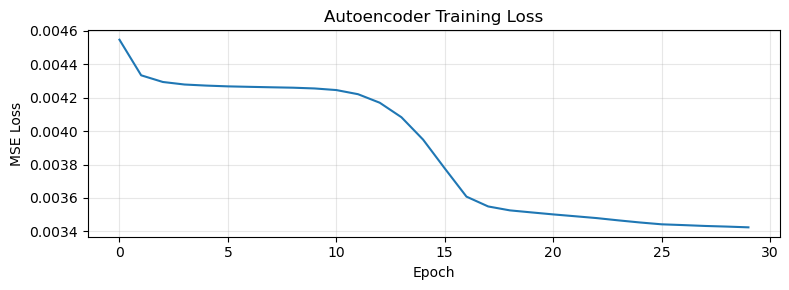

In [16]:
ae_model = ConvAutoencoder(seq_len=WINDOW, latent_dim=32)
print(ae_model)

losses = train_autoencoder(
    ae_model, normal_train_windows,
    epochs=30, batch_size=64, lr=1e-3, device=DEVICE
)

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('Autoencoder Training Loss')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

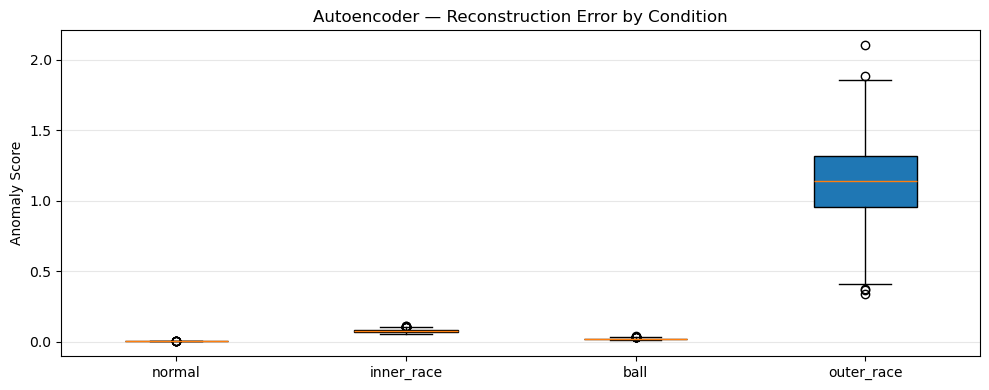

Conv1d Autoencoder PR-AUC: 1.0000


In [17]:
def score_windows(model, windows, device):
    """Get reconstruction error for a set of windows."""
    x = torch.tensor(windows[:, None, :]).float().to(device)
    return model.reconstruction_error(x)

ae_scores = {
    'normal': score_windows(ae_model, normal_test_windows, DEVICE),
    **{k: score_windows(ae_model, w, DEVICE) for k, w in fault_windows.items()}
}

plot_score_distribution(ae_scores, 'Autoencoder — Reconstruction Error by Condition')
plt.show()

all_scores_ae = np.concatenate([ae_scores['normal']] + [ae_scores[k] for k in fault_windows])
pr_auc_ae = pr_auc(all_labels, all_scores_ae)
print(f'Conv1d Autoencoder PR-AUC: {pr_auc_ae:.4f}')

## 8. Threshold Sweep — Operational Decision

### 💡 Explain This: Why PR-AUC ≈ 1.0 Is Not Suspicious Here

CWRU bearing faults at 0HP load produce extremely distinctive vibration signatures. An inner-race fault creates periodic impulses at a known multiple of shaft speed — visible in the raw signal and unmistakable in the FFT. Even a simple z-score on RMS amplitude will detect these faults.

PR-AUC ≈ 1.0 is **expected and documented** in CWRU benchmarking literature. It does NOT mean the model would achieve 1.0 on Niagara production data, which has:
- Variable loads (0HP, 1HP, 2HP, 3HP — fault frequencies shift with RPM)
- Background noise from adjacent machines on the production line
- Intermittent faults (appear and disappear under load variation)
- Sensor drift over months of deployment

**This is why we explicitly frame CWRU as a controlled benchmark, not a production claim.** The value of this dataset is learning the *workflow* — not benchmarking a deployable system.

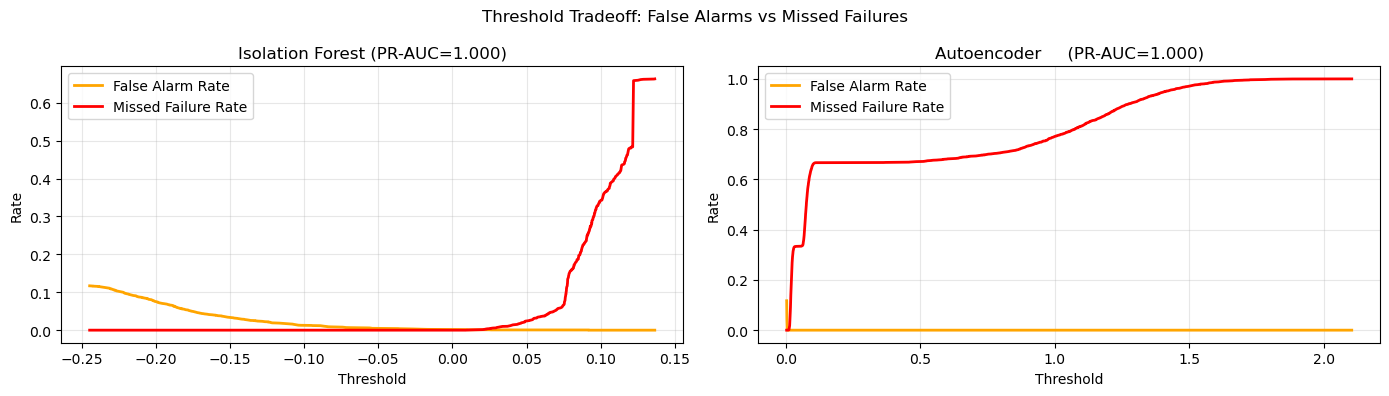

In [19]:
thresh_if, far_if, mfr_if = threshold_sweep(all_labels, all_scores_if)
thresh_ae, far_ae, mfr_ae = threshold_sweep(all_labels, all_scores_ae)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, thresh, far, mfr, title in [
    (axes[0], thresh_if, far_if, mfr_if, f'Isolation Forest (PR-AUC={pr_auc_if:.3f})'),
    (axes[1], thresh_ae, far_ae, mfr_ae, f'Autoencoder     (PR-AUC={pr_auc_ae:.3f})'),
]:
    ax.plot(thresh, far, label='False Alarm Rate', color='orange', linewidth=2)
    ax.plot(thresh, mfr, label='Missed Failure Rate', color='red', linewidth=2)
    ax.set_xlabel('Threshold'); ax.set_ylabel('Rate')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Threshold Tradeoff: False Alarms vs Missed Failures', fontsize=12)
plt.tight_layout(); plt.show()

### Interview Q: How do you pick a threshold in production?

**The threshold is a business decision, not a model decision.** The model gives you a score; the threshold converts it to an action — 'send a work order' or 'ignore'.

At Niagara (or any plant), the conversation is: *What does a false alarm cost vs. a missed failure?*

- A false work order = ~\$500 (technician time, unnecessary part swap)
- A missed motor failure = \$50K/hour downtime + possible safety incident

That's a 100:1 asymmetry → set the threshold aggressively low. Accept 15% false alarm rate to drive missed-failure rate below 2%.

Show the operations team this curve. Let *them* pick the operating point based on their cost model. The data scientist's job is to make the curve as good as possible; the operations team's job is to choose where on it they want to sit.